# Fit functions with pyoperon

This notebook mirrors `fit_functions.ipynb`, but instead of the LLM-driven genetic search it fits each function with [pyoperon](https://github.com/heal-research/pyoperon)'s `SymbolicRegressor`.

Note: the `pyoperon` binary shipped in the `~/llm` venv had a broken `@rpath` to `libz`/`libzstd`; a `/usr/lib` rpath was added (and the lib re-signed ad-hoc) so a plain `import pyoperon` works. If you reinstall pyoperon you may need to re-apply that fix or set `DYLD_FALLBACK_LIBRARY_PATH=/usr/lib` before launching the kernel.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pyoperon.sklearn import SymbolicRegressor

# Same scoring function the LLM search uses in fit_functions.ipynb, so the
# comparison is fair: score = -n_chi_squared (higher / closer to 0 is better).
from llmlex.fit import get_n_chi_squared_from_predictions

def llmlex_score(x, y, y_pred):
    return -get_n_chi_squared_from_predictions(x, y, y_pred)

In [2]:
funcs = [lambda x: (np.abs(np.sin(x))**0.5),
            lambda x: np.exp(( 1.83169 + (-3.35509 * (1 / x)))),
            lambda x: (x**3.),
            lambda x: ((1.44439 + (x**0.5)) * (np.pi + np.log(x))),
            lambda x: (3.09529 * (x**3.)),
            lambda x: ((np.pi + (x**3.))**2),
            lambda x: (51.2288 * np.cos((1.18219 * x))),
            lambda x: (-55.0512 * (1.0+(x**0.5))),
            lambda x: x,
            lambda x: (-0.0126997 + np.exp(np.cos(x))),
            lambda x: (1.54251 + (-1. * x)),
            lambda x: ((np.exp(2*x))),
            lambda x: (4.01209 + np.exp(x)),
            lambda x: ((-1. * np.pi) + (0.729202 * (x**0.5))),
            lambda x: (1.99594 + x + (-3. * ( x**3.))),
            lambda x: np.log(x+1),
            lambda x: np.sin(np.log((4.1746 * (1 / x)))),
            lambda x: (4.67315 + np.cos(np.exp(x))),
            lambda x: np.exp((-x))+2*np.exp(-3*x),
            lambda x: ((x**-3.) * np.sin(x))
            ]

print(len(funcs))

20


In [3]:
def make_regressor():
    return SymbolicRegressor(
        allowed_symbols='add,sub,mul,div,pow,exp,sin,cos,constant,variable,log,sqrt,abs,square',
        offspring_generator='basic',
        optimizer_iterations=10,
        max_length=30,
        initialization_method='btc',
        n_threads=8,
        objectives=['rmse', 'length'],
        epsilon=1e-3,
        random_state=None,
        reinserter='keep-best',
        max_evaluations=int(1e12),
        symbolic_mode=False,
        max_time=10,
        generations=int(1e12),
    )

# Run 1

## Search

Function 0


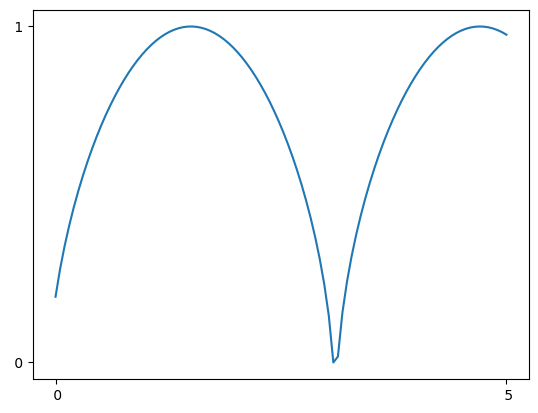

(0.73266 + (0.08781 * (0.23972 * X1)))
score: -3.2433738708496094
Function 1


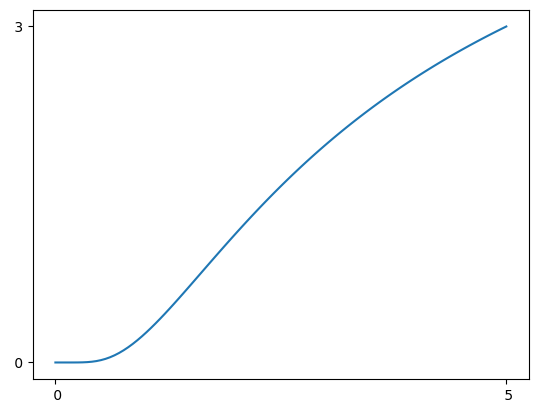

((-0.35340) + (1.26131 * (0.59748 * X1)))
score: -0.013717162422835827
Function 2


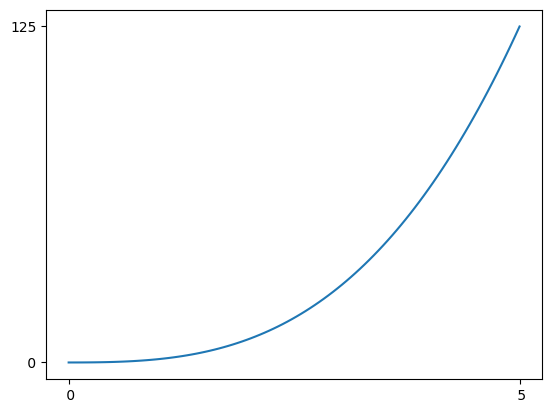

(0.00000 + ((-0.90241) * (((-1.03482) * X1) ^ 3.00000)))
score: -3.7730333858317436e-14
Function 3


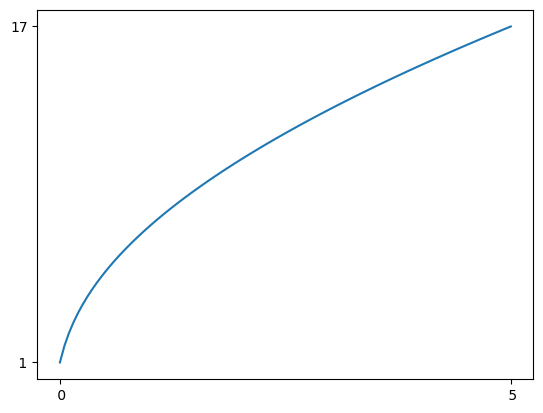

((-0.46078) + (1.04320 * sqrt((59.46938 * X1))))
score: -0.0008918651146814227
Function 4


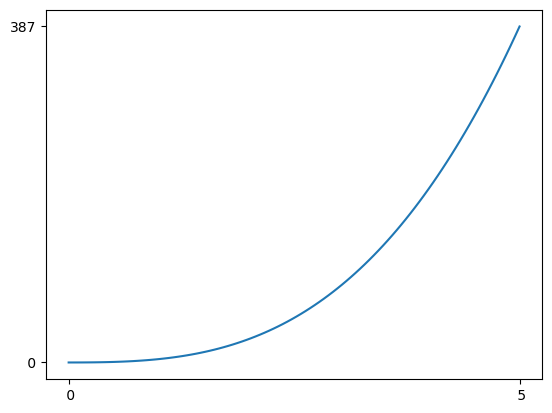

((-0.00001) + ((-25.44998) * (((-0.49546) * X1) ^ 3.00000)))
score: -4.5086571059732225e-14
Function 5


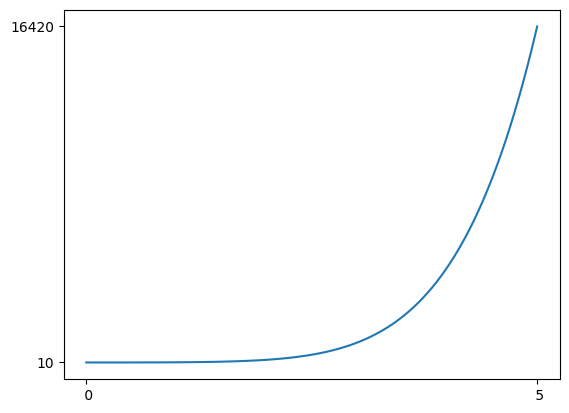

(0.00014 + (1.00000 * ((((1.00000 * X1) ^ 3.00000) - (-3.14159)) ^ 2)))
score: -4.250647576975464e-12
Function 6


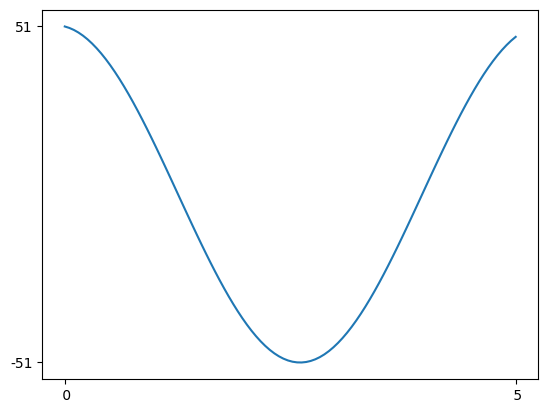

(0.00000 + (51.22880 * cos((1.18219 * X1))))
score: -4.947823021520664e-14
Function 7


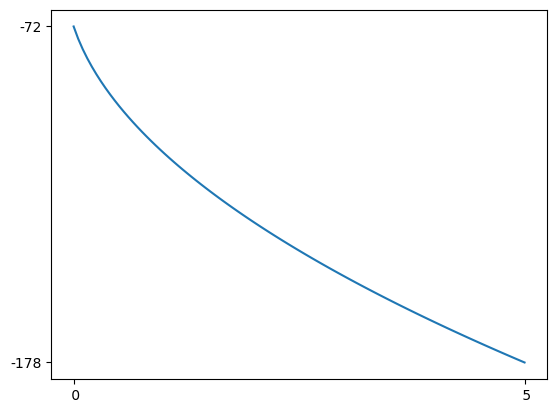

((-55.05120) + ((-32.63467) * sqrt((2.84561 * X1))))
score: -1.474202433304067e-13
Function 8


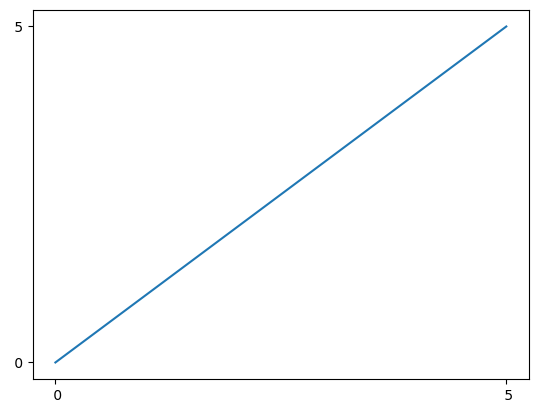

(1.00000 * X1)
score: -3.8870964518716074e-15
Function 9


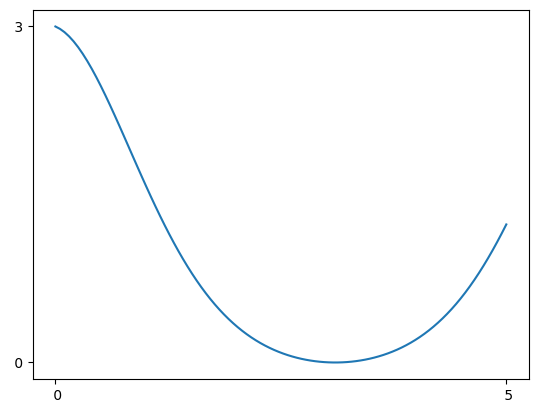

((-0.01270) + (1.00000 * exp(cos(((-1.00000) * X1)))))
score: -7.819954536344986e-14
Function 10


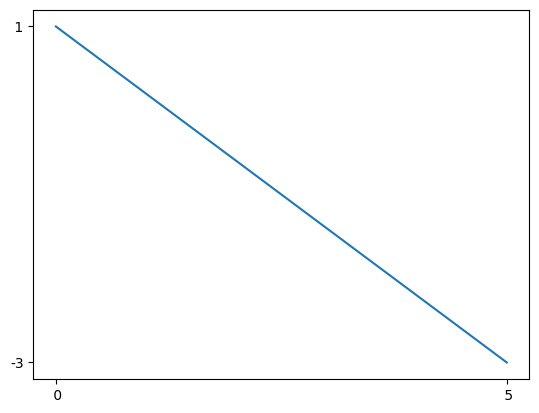

(1.54251 + (2.09486 * ((-0.47736) * X1)))
score: -9.446367231730028e-15
Function 11


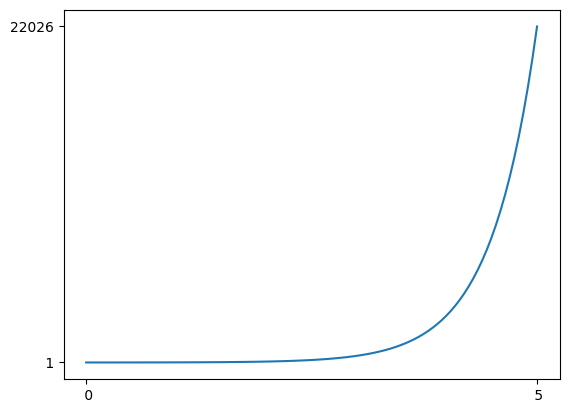

(0.00037 ^ ((-0.25290) * X1))
score: -1.0579762977150353e-12
Function 12


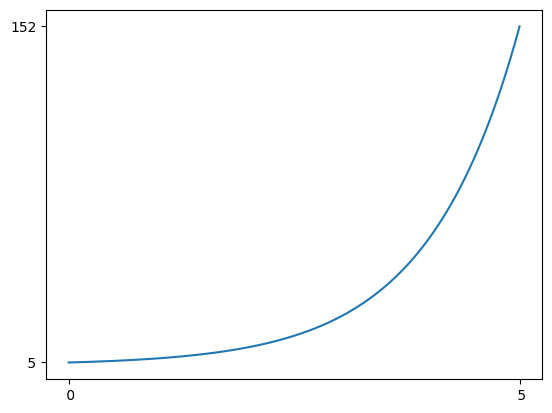

(4.01209 + (1.00000 * exp((1.00000 * X1))))
score: -5.525654803509306e-13
Function 13


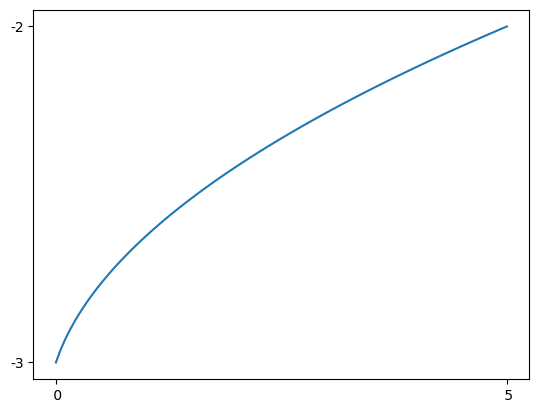

((-2.68595) + ((-0.26453) * ((-0.96157) * X1)))
score: -0.055409278720617294
Function 14


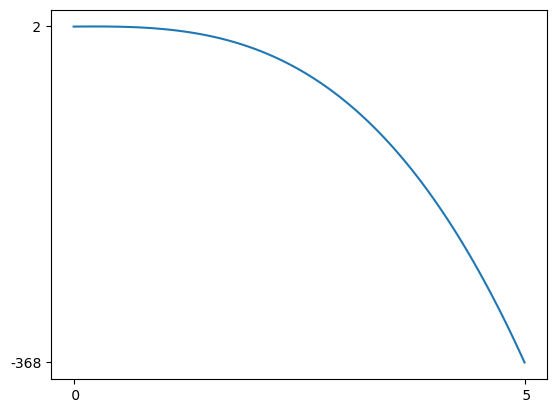

(2.75067 + ((-8.50587) * ((0.69418 * X1) ^ 3.03415)))
score: -2.2052017811802216e-05
Function 15


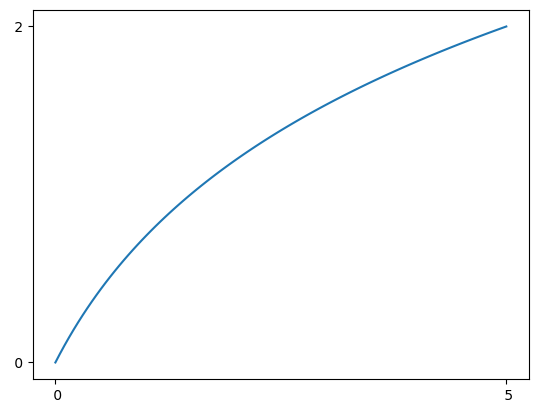

(0.36186 + ((-5727212.00000) * ((-0.00000) * X1)))
score: -0.08151794224977493
Function 16


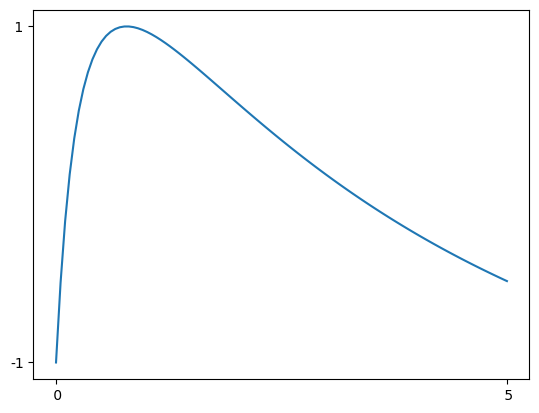

(0.95869 + ((-7.09992) * (0.02996 * X1)))
score: -0.48677805066108704
Function 17


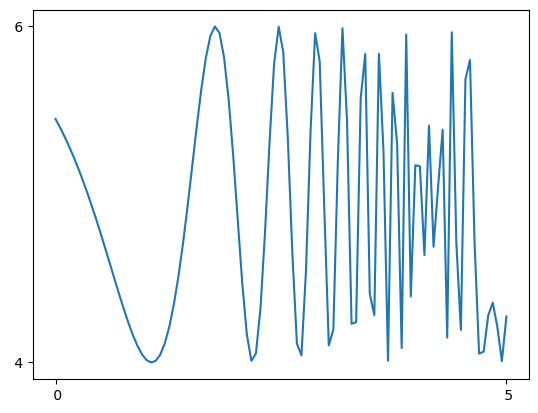

(4.67315 + (1.00000 * cos(exp((1.00000 * X1)))))
score: -4.147756790806589e-11
Function 18


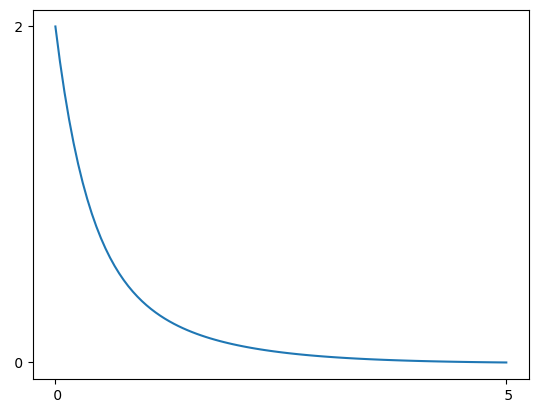

(0.03798 + (2.70261 * exp(((-1.85785) * X1))))
score: -0.19536620378494263
Function 19


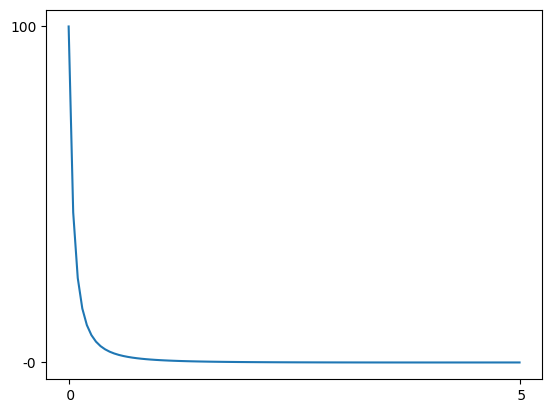

((-0.10466) + (1.00000 * ((1.00682 * X1) ^ (-2.00579))))
score: -0.4693084955215454


In [ ]:
xVals = np.linspace(0.1, 5, 100)
X = xVals.reshape(-1, 1)
count = 0
res_list = []

for func in funcs:
    print(f"Function {count}")
    count += 1
    y = func(xVals)

    fig, ax = plt.subplots()
    plt.xticks([xVals[0], xVals[-1]], ['%2.f' % xVals[0], '%2.f' % xVals[-1]])
    plt.yticks([min(y), max(y)], ['%2.f' % min(y), '%2.f' % max(y)])
    ax.plot(xVals, y)
    plt.show()

    reg = make_regressor()
    reg.fit(X, y)
    res_list.append(reg)

    y_pred = reg.predict(X)
    score = llmlex_score(xVals, y, y_pred)
    print(reg.get_model_string(reg.model_, 5))
    print(f"score: {score}")

## Compare

Function 0
(0.73266 + (0.08781 * (0.23972 * X1)))
score: -3.2433738708496094


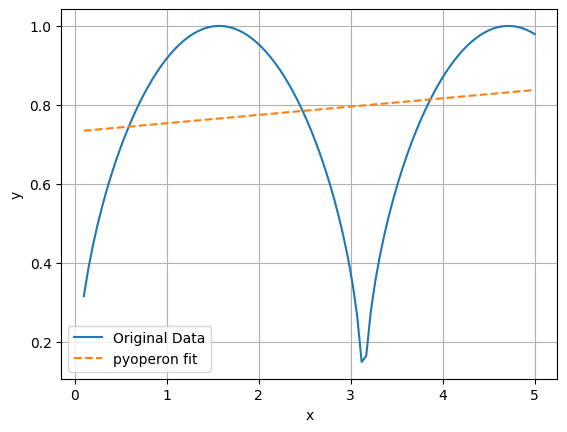

Function 1
((-0.35340) + (1.26131 * (0.59748 * X1)))
score: -0.013717162422835827


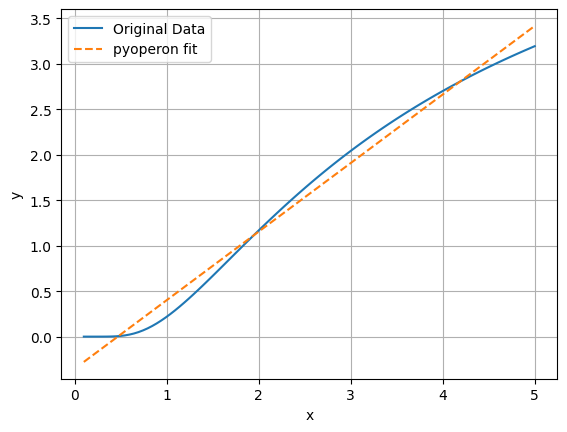

Function 2
(0.00000 + ((-0.90241) * (((-1.03482) * X1) ^ 3.00000)))
score: -3.7730333858317436e-14


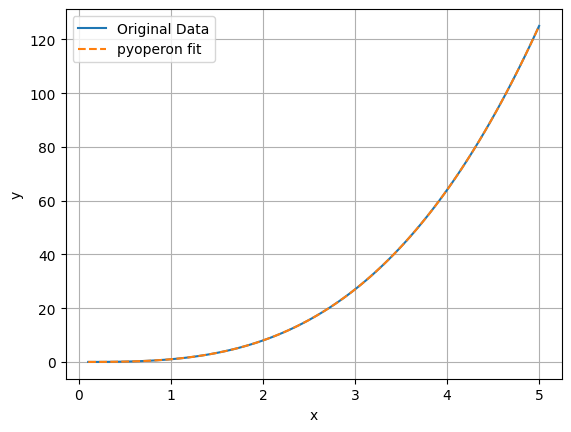

Function 3
((-0.46078) + (1.04320 * sqrt((59.46938 * X1))))
score: -0.0008918651146814227


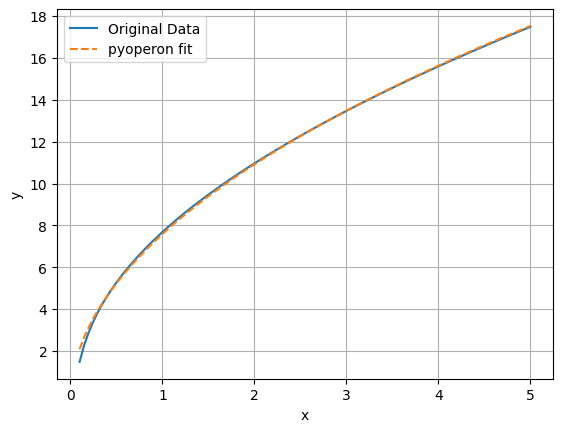

Function 4
((-0.00001) + ((-25.44998) * (((-0.49546) * X1) ^ 3.00000)))
score: -4.5086571059732225e-14


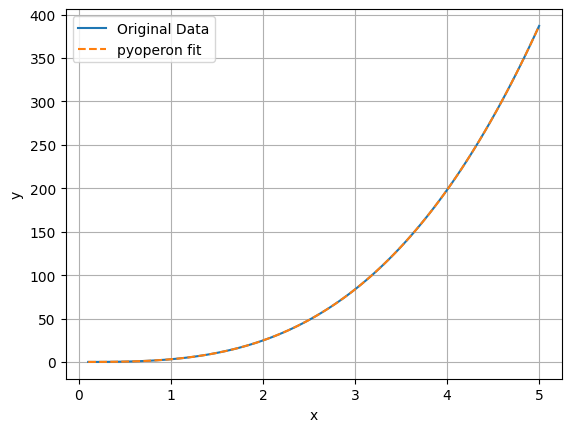

Function 5
(0.00014 + (1.00000 * ((((1.00000 * X1) ^ 3.00000) - (-3.14159)) ^ 2)))
score: -4.250647576975464e-12


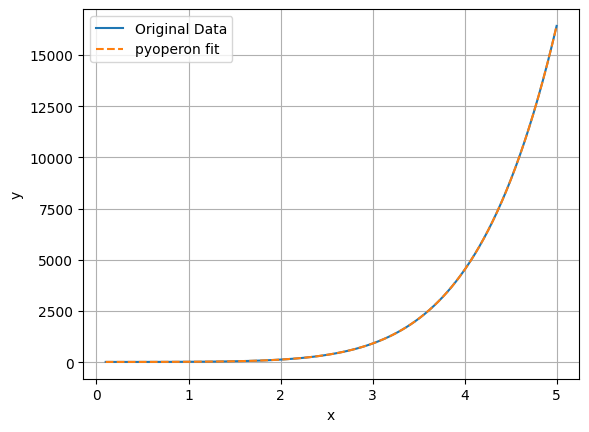

Function 6
(0.00000 + (51.22880 * cos((1.18219 * X1))))
score: -4.947823021520664e-14


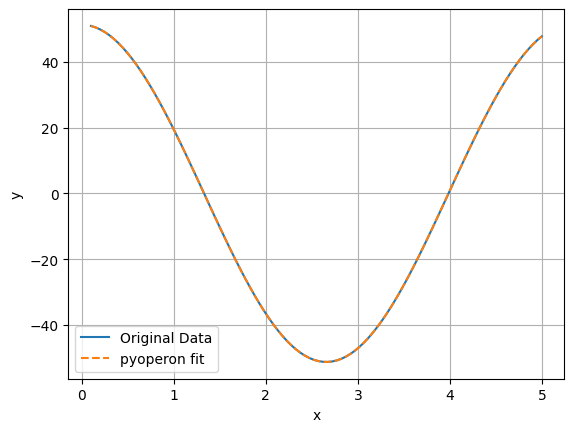

Function 7
((-55.05120) + ((-32.63467) * sqrt((2.84561 * X1))))
score: -1.474202433304067e-13


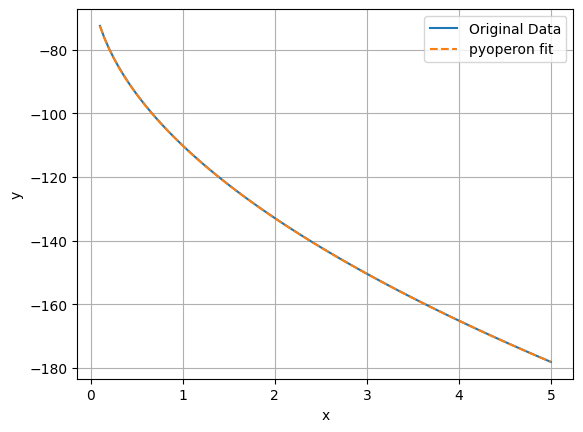

Function 8
(1.00000 * X1)
score: -3.8870964518716074e-15


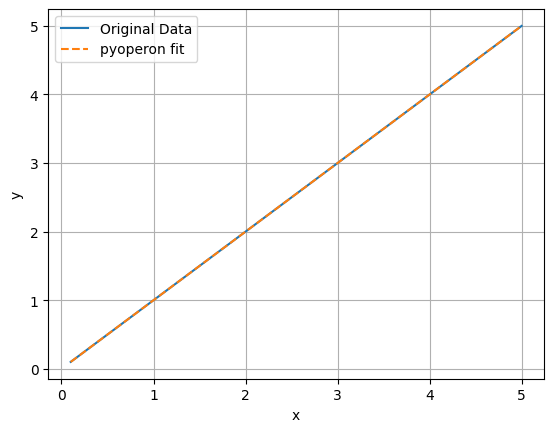

Function 9
((-0.01270) + (1.00000 * exp(cos(((-1.00000) * X1)))))
score: -7.819954536344986e-14


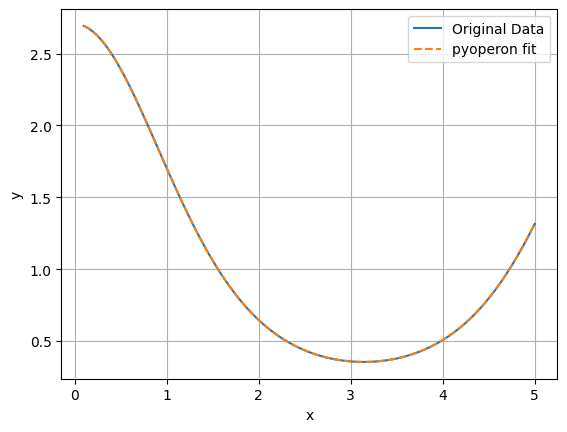

Function 10
(1.54251 + (2.09486 * ((-0.47736) * X1)))
score: -9.446367231730028e-15


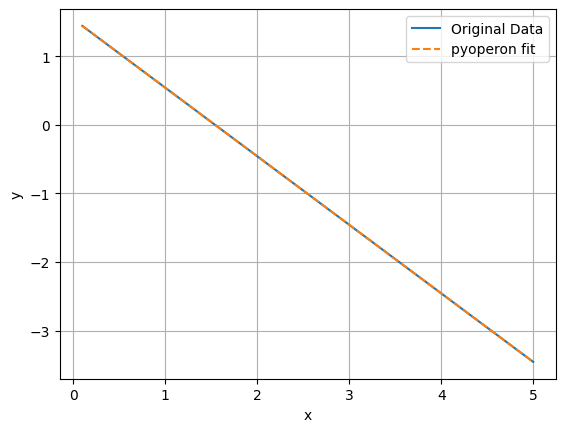

Function 11
(0.00037 ^ ((-0.25290) * X1))
score: -1.0579762977150353e-12


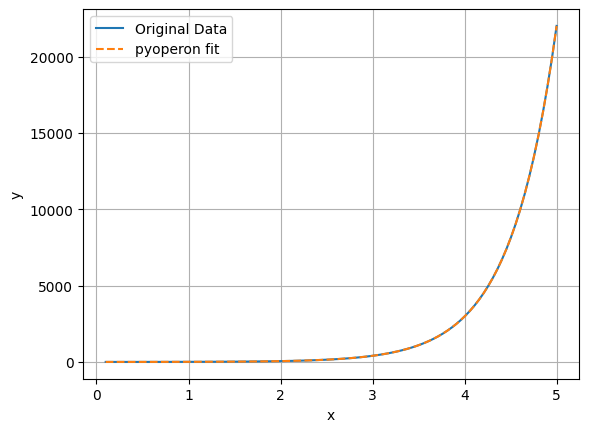

Function 12
(4.01209 + (1.00000 * exp((1.00000 * X1))))
score: -5.525654803509306e-13


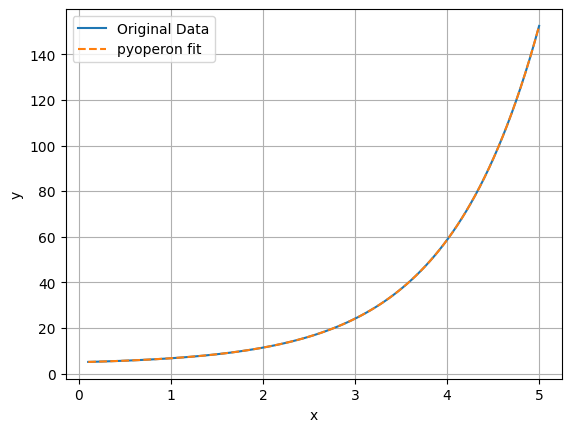

Function 13
((-2.68595) + ((-0.26453) * ((-0.96157) * X1)))
score: -0.055409278720617294


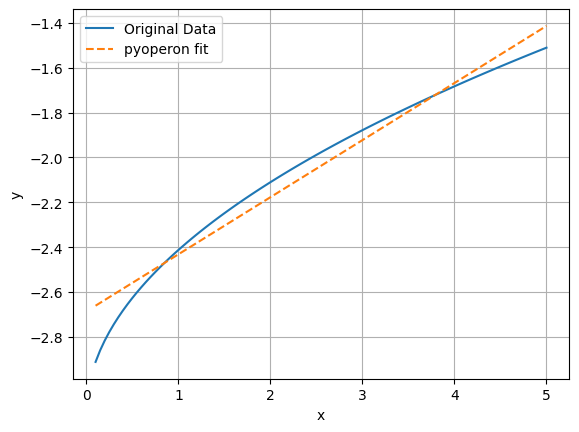

Function 14
(2.75067 + ((-8.50587) * ((0.69418 * X1) ^ 3.03415)))
score: -2.2052017811802216e-05


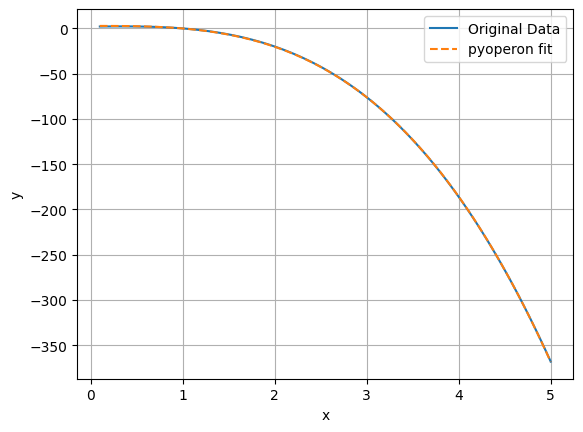

Function 15
(0.36186 + ((-5727212.00000) * ((-0.00000) * X1)))
score: -0.08151794224977493


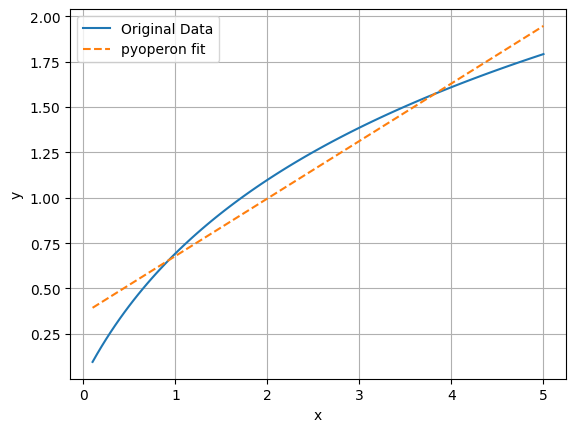

Function 16
(0.95869 + ((-7.09992) * (0.02996 * X1)))
score: -0.48677805066108704


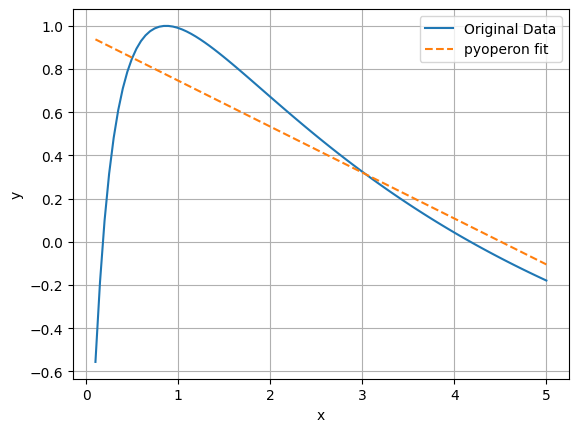

Function 17
(4.67315 + (1.00000 * cos(exp((1.00000 * X1)))))
score: -4.147756790806589e-11


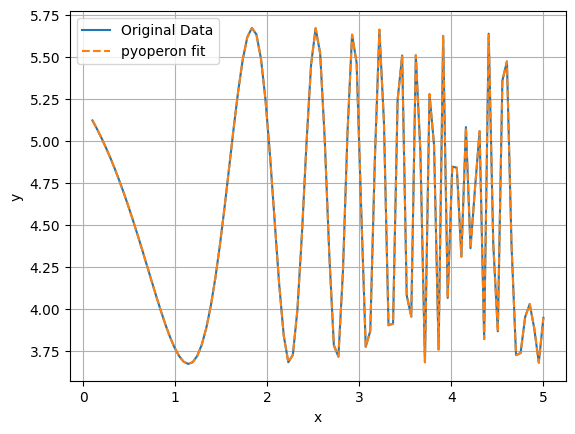

Function 18
(0.03798 + (2.70261 * exp(((-1.85785) * X1))))
score: -0.19536620378494263


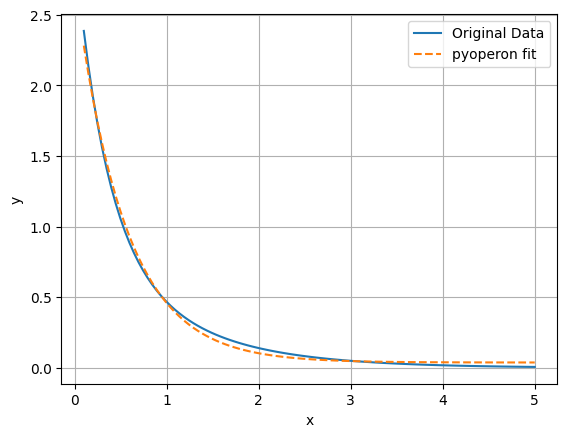

Function 19
((-0.10466) + (1.00000 * ((1.00682 * X1) ^ (-2.00579))))
score: -0.4693084955215454


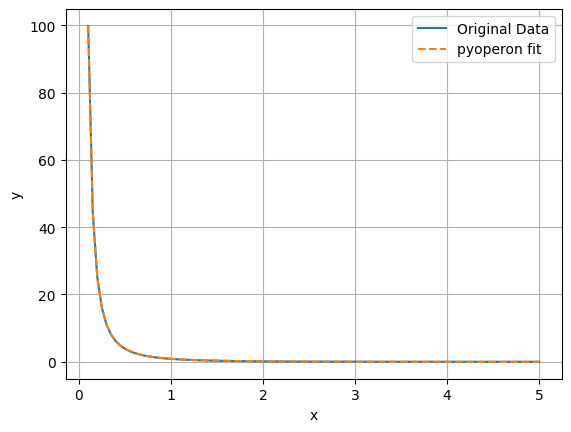

In [5]:
for index in range(len(res_list)):
    print(f"Function {index}")
    y = funcs[index](xVals)
    reg = res_list[index]

    y_pred = reg.predict(X)
    score = llmlex_score(xVals, y, y_pred)
    print(reg.get_model_string(reg.model_, 5))
    print(f"score: {score}")

    # Plot the original data
    plt.plot(xVals, y, label='Original Data')

    # Plot the pyoperon fit
    plt.plot(xVals, y_pred, label='pyoperon fit', linestyle='--')

    # Add labels and legend
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()